In this notebook, I follow the OSCA book scRNA data analysis workflow in chapter 2 analyzing Zeisel et al. mouse brain data. 

In [1]:
getwd()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [2]:
Sys.getlocale() |> print()

[1] "LC_CTYPE=C;LC_NUMERIC=C;LC_TIME=C;LC_COLLATE=C;LC_MONETARY=C;LC_MESSAGES=C.UTF-8;LC_PAPER=C;LC_NAME=C;LC_ADDRESS=C;LC_TELEPHONE=C;LC_MEASUREMENT=C;LC_IDENTIFICATION=C"


In [3]:
renv::load()

Warning message in Sys.setlocale():
"OS reports request to set locale to "" cannot be honored"
Warning message in Sys.setlocale():
"OS reports request to set locale to "" cannot be honored"
Warning message in Sys.setlocale():
"OS reports request to set locale to "" cannot be honored"
Warning message in Sys.setlocale():
"OS reports request to set locale to "" cannot be honored"
Warning message in Sys.setlocale():
"OS reports request to set locale to "" cannot be honored"
Warning message in Sys.setlocale():
"OS reports request to set locale to "" cannot be honored"
Warning message in Sys.setlocale():
"OS reports request to set locale to "" cannot be honored"
Warning message in Sys.setlocale():
"OS reports request to set locale to "" cannot be honored"
Warning message in Sys.setlocale():
"OS reports request to set locale to "" cannot be honored"
Warning message in Sys.setlocale():
"OS reports request to set locale to "" cannot be honored"
Warning message in Sys.setlocale():
"OS reports re

In [5]:
.libPaths()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/renv/library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu"
[2] "/fast/home/y/ykazci/.cache/R/renv/sandbox/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu/233218af"

In [6]:
library(Seurat)

Loading required package: SeuratObject

Loading required package: sp

'SeuratObject' was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall 'SeuratObject' as the ABI
for R may have changed


Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t




In [7]:
detach("package:Seurat")

In [8]:
library(scater)

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: 'MatrixGenerics'


The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    

In [9]:
here::here()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [10]:
sce_RNA <- readRDS(here::here('r_objects', 'GeneExpressionMatrix.RDS'))

In [11]:
sce_RNA

class: SingleCellExperiment 
dim: 20667 49470 
metadata(0):
assays(3): counts logcounts scaledata
rownames(20667): ENSG00000279457 ENSG00000237491 ... ENSG00000188120
  ENSG00000205944
rowData names(2): gene_id gene_name
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(89): orig.ident nCount_RNA ... main_cell_types ident
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [12]:
unfiltered <- sce_RNA

In [14]:
sce_RNA |> rowData() |> head()

DataFrame with 6 rows and 2 columns
                        gene_id   gene_name
                    <character> <character>
ENSG00000279457 ENSG00000279457      WASH9P
ENSG00000237491 ENSG00000237491   LINC01409
ENSG00000177757 ENSG00000177757      FAM87B
ENSG00000230368 ENSG00000230368      FAM41C
ENSG00000223764 ENSG00000223764   LINC02593
ENSG00000187634 ENSG00000187634      SAMD11

In [15]:
library(org.Hs.eg.db)

Loading required package: AnnotationDbi





In [16]:
sce_RNA |> row.names() |> head()

[1] "ENSG00000279457" "ENSG00000237491" "ENSG00000177757" "ENSG00000230368"
[5] "ENSG00000223764" "ENSG00000187634"

In [18]:
org.Hs.eg.db |> columns()

[1] "ACCNUM"       "ALIAS"        "ENSEMBL"      "ENSEMBLPROT"  "ENSEMBLTRANS"
 [6] "ENTREZID"     "ENZYME"       "EVIDENCE"     "EVIDENCEALL"  "GENENAME"    
[11] "GENETYPE"     "GO"           "GOALL"        "IPI"          "MAP"         
[16] "OMIM"         "ONTOLOGY"     "ONTOLOGYALL"  "PATH"         "PFAM"        
[21] "PMID"         "PROSITE"      "REFSEQ"       "SYMBOL"       "UCSCKG"      
[26] "UNIPROT"

In [19]:
rowData(sce_RNA)$GENETYPE <- mapIds(org.Hs.eg.db, 
    keys=rownames(sce_RNA), keytype="ENSEMBL", column="GENETYPE")

'select()' returned 1:many mapping between keys and columns



In [20]:
rowData(sce_RNA)$GENETYPE |> table()


         ncRNA protein-coding         pseudo        unknown 
          1721          18012             15              1 

In [21]:
sce_RNA |> colData() |> head()

DataFrame with 6 rows and 89 columns
                          orig.ident nCount_RNA nFeature_RNA
                            <factor>  <numeric>    <integer>
10X280_1:CAGATTCAGCAGCTCA     10X280       4735         2198
10X365_2:ACCAATATCAATGACC     10X365       4031         1628
10X365_2:ATGGTGCGTCACCTAT     10X365       4454         1277
10X280_1:ACACCTTGTCATTAGG     10X280       3976         1850
10X406_1:TATCGCGAGGCTTAAC     10X406       3896         1631
10X280_1:ACCTTGCTCCGTAAAC     10X280       3794         1556
                          before_filtering_orig.ident
                                             <factor>
10X280_1:CAGATTCAGCAGCTCA                      10X280
10X365_2:ACCAATATCAATGACC                      10X365
10X365_2:ATGGTGCGTCACCTAT                      10X365
10X280_1:ACACCTTGTCATTAGG                      10X280
10X406_1:TATCGCGAGGCTTAAC                      10X406
10X280_1:ACCTTGCTCCGTAAAC                      10X280
                          before_filtering_

In [22]:
library(scran)
set.seed(1000)

In [23]:
clusters <- quickCluster(sce_RNA)

In [24]:
clusters |> table()

clusters
   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
5794 1951 4787 2225 6250 2079  830 2149  439 6771 2278  368 2055 1960 2786  184 
  17   18   19   20   21   22   23   24   25   26   27   28 
 356  165 2073  220 1299  306  371  935  432  149  137  121 

In [25]:
sce_RNA <- computeSumFactors(sce_RNA, cluster=clusters) 

In [26]:
sce_RNA |> colData() |> colnames()

[1] "orig.ident"                    "nCount_RNA"                   
 [3] "nFeature_RNA"                  "before_filtering_orig.ident"  
 [5] "before_filtering_nCount_RNA"   "before_filtering_nFeature_RNA"
 [7] "X_index"                       "Age"                          
 [9] "Agetext"                       "Ageunit"                      
[11] "All_fc_analysis_id"            "Analysis"                     
[13] "CellCycle"                     "CellCycle_G1"                 
[15] "CellCycle_G2M"                 "CellCycle_S"                  
[17] "CellID"                        "Chemistry"                    
[19] "Class"                         "ClusterName"                  
[21] "Clusters"                      "Clusters_main"                
[23] "Clusters_peaks"                "Clusters_renumbered"          
[25] "Cmobarcodes"                   "Comment"                      
[27] "Datecaptured"                  "Donor"                        
[29] "DoubletFinderFlag"             "DoubletFinderScore"           
[31] "Editat"                        "Editby"                       
[33] "FRIP"                          "FRtss"                        
[35] "GA_colsum"                     "GA_pooled_colsum"             
[37] "Id"                            "IsCycling"                    
[39] "Label"                         "Method"                       
[41] "NBins"                         "NGenes"                       
[43] "NPeaks"                        "Name"                         
[45] "Neuronprop"                    "Numpooledanimals"             
[47] "Outliers"                      "Plugdate"                     
[49] "Project"                       "PseudoAge"                    
[51] "Roi"                           "SEX"                          
[53] "Sampleok"                      "Sex"                          
[55] "Shortname"                     "Species"                      
[57] "Split"                         "Splits"                       
[59] "Strain"                        "SubClusters"                  
[61] "TSS_fragments"                 "Tissue"                       
[63] "TotalUMI"                      "Transcriptome"                
[65] "Y"                             "barcode"                      
[67] "chimeric"                      "duplicate"                    
[69] "excluded_reason"               "is__cell_barcode"             
[71] "lowmapq"                       "mitochondrial"                
[73] "passed_filters"                "peak_region_cutsites"         
[75] "peak_region_fragments"         "preClusters"                  
[77] "regions"                       "subregions"                   
[79] "total"                         "unmapped"                     
[81] "before_filtering_percent.mt"   "UMAP_1"                       
[83] "UMAP_2"                        "PC_1"                         
[85] "PC_2"                          "PC_3"                         
[87] "PC_4"                          "main_cell_types"              
[89] "ident"                         "sizeFactor"

In [27]:
sce_RNA <- logNormCounts(sce_RNA)

In [28]:
summary(sizeFactors(sce_RNA))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.03947 0.67908 1.06826 1.00000 1.25536 2.05112 

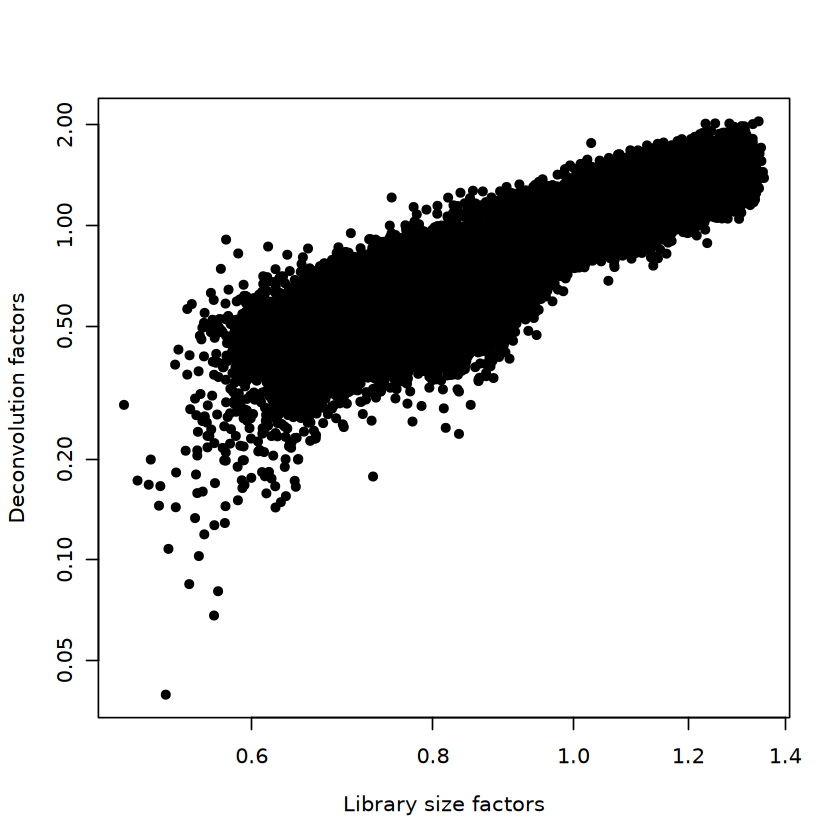

In [29]:
plot(librarySizeFactors(sce_RNA), sizeFactors(sce_RNA), pch=16,
    xlab="Library size factors", ylab="Deconvolution factors", log="xy")

In [30]:
# We create a mean-variance trend based on the expectation that counts have Poisson technical noise:

set.seed(00010101)

dec_sce_rna <- modelGeneVarByPoisson(sce_RNA) 

In [31]:
top_sce_rna <- getTopHVGs(dec_sce_rna, prop=0.1)

ERROR: Error in eval(expr, envir = ll, enclos = parent.frame()): attempt to apply non-function


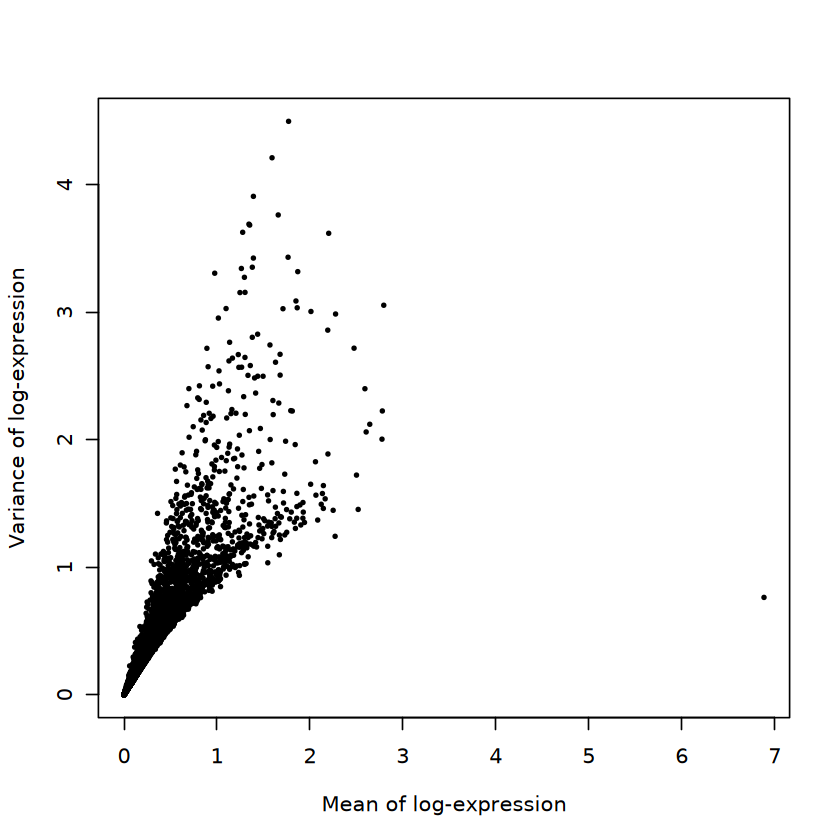

In [34]:
plot(dec_sce_rna$mean, dec_sce_rna$total, pch=16, cex=0.5,
    xlab="Mean of log-expression", ylab="Variance of log-expression")
curfit <- metadata(dec_sce_rna)
curve(dec_sce_rna$trend(x), col='dodgerblue', add=TRUE, lwd=2)

In [33]:
curfit |> head()

$mean
   [1] 0.000000e+00 1.644590e-05 0.000000e+00 1.608850e-05 0.000000e+00
   [6] 0.000000e+00 3.885477e-05 0.000000e+00 1.630635e-05 0.000000e+00
  [11] 0.000000e+00 0.000000e+00 1.685827e-05 1.750896e-05 0.000000e+00
  [16] 1.626250e-05 0.000000e+00 1.928230e-05 0.000000e+00 3.550537e-05
  [21] 4.954038e-05 2.950128e-05 1.720475e-05 1.621965e-05 2.956868e-05
  [26] 1.503816e-05 1.634357e-05 2.959167e-05 0.000000e+00 1.659820e-05
  [31] 0.000000e+00 2.045997e-05 1.814677e-05 0.000000e+00 1.879001e-05
  [36] 0.000000e+00 1.906211e-05 0.000000e+00 0.000000e+00 0.000000e+00
  [41] 0.000000e+00 0.000000e+00 2.105791e-05 0.000000e+00 1.955048e-05
  [46] 3.405436e-05 0.000000e+00 1.970777e-05 0.000000e+00 1.795587e-05
  [51] 4.821566e-05 4.248268e-05 0.000000e+00 1.745159e-05 1.620437e-05
  [56] 0.000000e+00 3.232742e-05 3.526157e-05 2.094004e-05 3.204984e-05
  [61] 0.000000e+00 5.042448e-05 1.458364e-05 6.751526e-05 1.835921e-05
  [66] 1.684394e-05 4.586415e-05 3.385254e-05 5.495154e-05 1.811148e-05
  [71] 0.000000e+00 6.910841e-05 5.134711e-05 3.689713e-05 0.000000e+00
  [76] 1.600887e-05 4.606641e-05 1.593375e-05 5.785425e-05 3.470917e-05
  [81] 0.000000e+00 5.714778e-05 1.384720e-04 4.017361e-05 7.937423e-05
  [86] 0.000000e+00 6.111235e-05 0.000000e+00 4.920995e-05 1.687956e-05
  [91] 9.846145e-05 1.408226e-05 3.230832e-05 5.219484e-05 3.661986e-05
  [96] 0.000000e+00 5.410300e-05 2.000451e-05 9.994098e-05 5.294337e-05
 [101] 1.513677e-05 1.753331e-05 1.535290e-05 1.474449e-05 8.218922e-05
 [106] 8.141206e-05 1.716235e-05 9.242814e-05 3.165848e-05 4.737805e-05
 [111] 7.508976e-05 8.981863e-05 3.484516e-05 7.012095e-05 1.098039e-04
 [116] 3.410491e-05 7.082416e-05 5.753904e-05 1.893069e-05 0.000000e+00
 [121] 4.942323e-05 5.144569e-05 3.500083e-05 3.485969e-05 6.990541e-05
 [126] 3.534963e-05 1.092218e-04 1.107119e-04 7.655370e-05 4.026459e-05
 [131] 7.277229e-05 2.246672e-05 1.632567e-05 6.392115e-05 8.690210e-05
 [136] 1.154608e-04 7.337115e-05 1.221637e-04 1.695639e-04 5.213789e-05
 [141] 4.674702e-05 2.076848e-05 8.796143e-05 1.550864e-04 1.234513e-04
 [146] 9.462444e-05 9.888197e-05 1.067968e-04 1.524995e-04 1.419311e-04
 [151] 1.475559e-04 1.340233e-04 1.459116e-04 1.463647e-04 8.306039e-05
 [156] 1.830713e-04 1.475467e-04 2.077922e-04 1.485585e-04 8.187910e-05
 [161] 8.164249e-05 1.519483e-04 8.750055e-05 1.296858e-04 1.748832e-05
 [166] 1.159397e-04 5.213463e-05 1.656977e-04 2.588536e-04 1.545906e-04
 [171] 1.281055e-04 2.783653e-04 1.518496e-04 1.295849e-04 1.617465e-04
 [176] 1.282395e-04 1.075173e-04 5.212051e-05 1.922846e-04 6.210221e-05
 [181] 1.552321e-04 1.929994e-04 1.273608e-04 2.241872e-04 1.885571e-04
 [186] 1.311742e-04 1.697203e-04 1.957309e-04 2.222211e-04 1.888574e-04
 [191] 6.934562e-05 1.488216e-04 2.041268e-04 2.655156e-04 3.473158e-04
 [196] 1.771450e-04 2.223768e-04 2.443696e-04 3.630642e-04 2.127197e-04
 [201] 1.585365e-04 1.082576e-04 3.629836e-04 2.886610e-04 2.429573e-04
 [206] 3.116362e-04 2.772003e-04 2.271131e-04 3.088548e-04 2.799067e-04
 [211] 2.794784e-04 3.148596e-04 2.732427e-04 2.455313e-04 2.436460e-04
 [216] 1.922327e-04 4.221269e-04 2.462769e-04 2.729783e-04 2.310832e-04
 [221] 3.731511e-04 3.163355e-04 2.897409e-04 4.975867e-04 4.230668e-04
 [226] 5.516893e-04 4.173912e-04 3.126900e-04 3.299006e-04 4.087524e-04
 [231] 3.303458e-04 4.330097e-04 3.995313e-04 3.291799e-04 3.572392e-04
 [236] 3.286421e-04 4.065289e-04 4.928557e-04 4.135155e-04 5.112941e-04
 [241] 4.882729e-04 6.140741e-04 3.694146e-04 4.883472e-04 5.858322e-04
 [246] 3.699115e-04 3.668181e-04 4.665370e-04 6.970593e-04 5.639222e-04
 [251] 4.997819e-04 5.680964e-04 4.666647e-04 6.205045e-04 5.624619e-04
 [256] 6.714551e-04 4.890700e-04 7.141481e-04 5.528405e-04 4.059967e-04
 [261] 6.847470e-04 5.578616e-04 7.801916e-04 6.864575e-04 4.024082e-04
 [266] 6.301495e-04 9.346481e-04 9.780418e-04 8.424585e-04 8.649579e-04
 [271] 8.924485e-04 7.817599e-04 9.274001e-04 9.363246e-04 7.611892e-04
 [276] 9.907275e-04 7.279022e-04 7

In [35]:
class(dec_sce_rna$trend)

[1] "NULL"

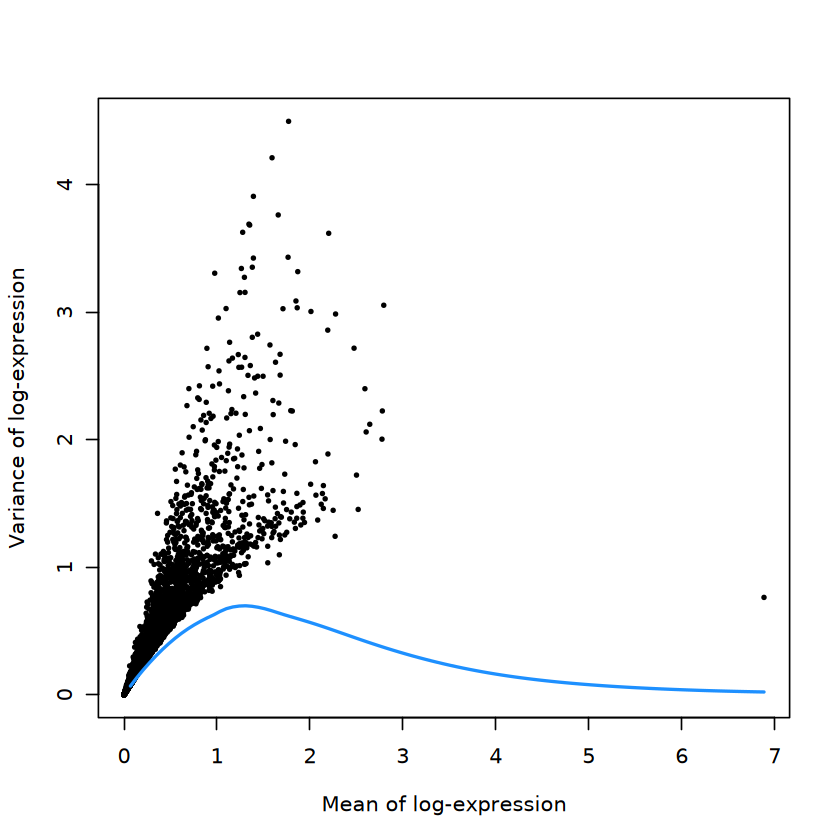

In [36]:
plot(dec_sce_rna$mean, dec_sce_rna$total, pch=16, cex=0.5,
    xlab="Mean of log-expression", ylab="Variance of log-expression")

curfit <- metadata(dec_sce_rna)$trend
curve(curfit(x), col='dodgerblue', add=TRUE, lwd=2)

In [38]:
class(curfit)

[1] "function"

In [39]:
library(BiocSingular)

In [40]:
set.seed(101011001)

In [41]:
sce_RNA <- denoisePCA(sce_RNA, technical=dec_sce_rna, subset.row=top_sce_rna)

In [42]:
ncol(reducedDim(sce_RNA, "PCA"))

[1] 50

In [43]:
sce_RNA <- runUMAP(sce_RNA, dimred="PCA")

In [44]:
snn.gr <- buildSNNGraph(sce_RNA, use.dimred="PCA")

In [45]:
colLabels(sce_RNA) <- factor(igraph::cluster_walktrap(snn.gr)$membership)

In [46]:
table(colLabels(sce_RNA))


   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
1769 1889 4607 1930 1887 1636 1948  587 2880  211  302  296 2827  773  155 4350 
  17   18   19   20   21   22   23   24   25   26   27   28   29   30   31   32 
 338 3884  157  600  846 3767  363 2425  454  770  221  428  715  138  541  664 
  33   34   35   36   37   38   39   40   41   42   43   44   45   46   47   48 
 179  194  195  430  915  248  423  101  381  495  278   43  142  138  151  143 
  49   50   51   52   53   54   55   56   57   58 
 191   39   83   48   76   80   16   64   29   30 

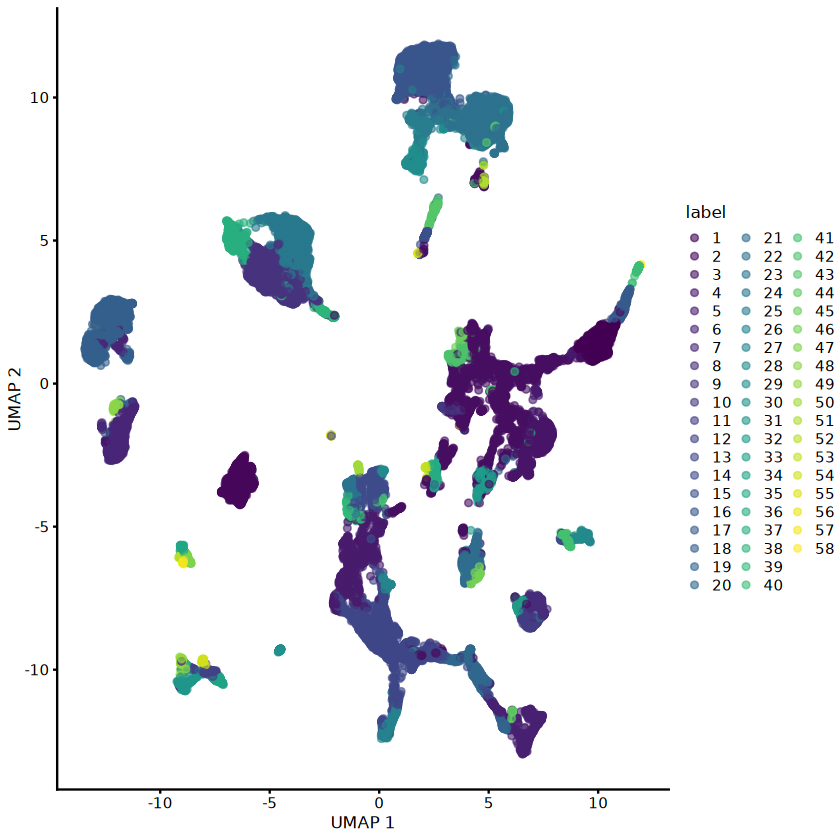

In [47]:
plotUMAP(sce_RNA, colour_by="label")

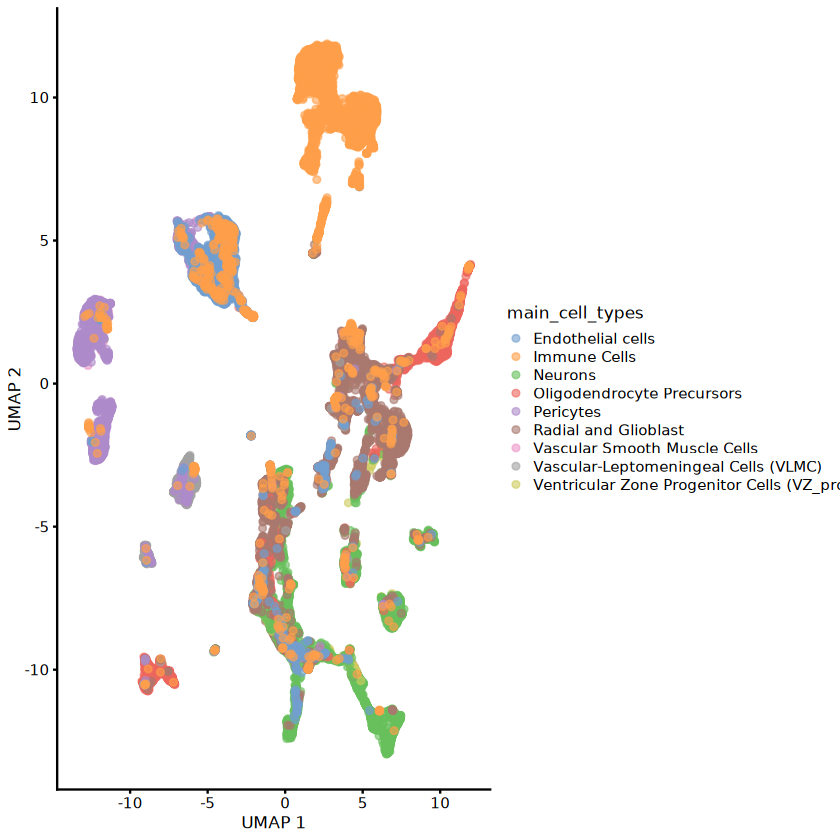

In [48]:
plotUMAP(sce_RNA, colour_by="main_cell_types")

In [50]:
colLabels(sce_RNA) |> levels()

[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14" "15"
[16] "16" "17" "18" "19" "20" "21" "22" "23" "24" "25" "26" "27" "28" "29" "30"
[31] "31" "32" "33" "34" "35" "36" "37" "38" "39" "40" "41" "42" "43" "44" "45"
[46] "46" "47" "48" "49" "50" "51" "52" "53" "54" "55" "56" "57" "58"

In [51]:
colLabels(sce_RNA) <- sce_RNA$main_cell_types

In [53]:
colLabels(sce_RNA) |> table()


                          Endothelial cells 
                                       5139 
                               Immune Cells 
                                      10845 
                                    Neurons 
                                       9670 
                 Oligodendrocyte Precursors 
                                       4508 
                                  Pericytes 
                                       6484 
                       Radial and Glioblast 
                                       9593 
               Vascular Smooth Muscle Cells 
                                        567 
       Vascular-Leptomeningeal Cells (VLMC) 
                                       2334 
Ventricular Zone Progenitor Cells (VZ_prog) 
                                        330 

In [54]:
markers <- findMarkers(sce_RNA, direction="up")

In [57]:
marker.set <- markers[["Endothelial cells"]]

In [58]:
marker.set |> head()

DataFrame with 6 rows and 12 columns
                      Top   p.value       FDR summary.logFC logFC.Immune Cells
                <integer> <numeric> <numeric>     <numeric>          <numeric>
ENSG00000110799         1         0         0       2.01047            1.90640
ENSG00000102755         1         0         0       4.09146            3.92935
ENSG00000128849         1         0         0       2.37870            2.32612
ENSG00000103257         1         0         0       3.50261            3.35073
ENSG00000144724         1         0         0       3.20940            3.20940
ENSG00000085276         1         0         0       3.43201            3.37061
                logFC.Neurons logFC.Oligodendrocyte Precursors logFC.Pericytes
                    <numeric>                        <numeric>       <numeric>
ENSG00000110799       2.01047                          1.98692         1.68846
ENSG00000102755       4.12312                          4.09146         2.88875
ENSG00000128849

In [59]:
head(marker.set[,1:8], 10) # only first 8 columns, for brevity

DataFrame with 10 rows and 8 columns
                      Top   p.value       FDR summary.logFC logFC.Immune Cells
                <integer> <numeric> <numeric>     <numeric>          <numeric>
ENSG00000110799         1         0         0       2.01047            1.90640
ENSG00000102755         1         0         0       4.09146            3.92935
ENSG00000128849         1         0         0       2.37870            2.32612
ENSG00000103257         1         0         0       3.50261            3.35073
ENSG00000144724         1         0         0       3.20940            3.20940
ENSG00000085276         1         0         0       3.43201            3.37061
ENSG00000158321         1         0         0       2.98713            2.98713
ENSG00000047617         2         0         0       1.60760            1.57723
ENSG00000170558         2         0         0       3.45955            3.45955
ENSG00000196628         2         0         0       3.18388            3.18388
               

In [60]:
rownames(sce_RNA) |> head()

[1] "ENSG00000279457" "ENSG00000237491" "ENSG00000177757" "ENSG00000230368"
[5] "ENSG00000223764" "ENSG00000187634"

In [61]:
rowData(sce_RNA) |> head()

DataFrame with 6 rows and 3 columns
                        gene_id   gene_name       GENETYPE
                    <character> <character>    <character>
ENSG00000279457 ENSG00000279457      WASH9P             NA
ENSG00000237491 ENSG00000237491   LINC01409          ncRNA
ENSG00000177757 ENSG00000177757      FAM87B          ncRNA
ENSG00000230368 ENSG00000230368      FAM41C          ncRNA
ENSG00000223764 ENSG00000223764   LINC02593          ncRNA
ENSG00000187634 ENSG00000187634      SAMD11 protein-coding

In [69]:
rowData(sce_RNA) |> as.data.frame() |> dplyr::pull(gene_name) |> duplicated() |> table()


FALSE 
20667 

In [70]:
table(rowData(sce_RNA)$gene_id == rownames(sce_RNA))


 TRUE 
20667 

In [71]:
rownames(sce_RNA) <- rowData(sce_RNA)$gene_name

In [72]:
markers <- findMarkers(sce_RNA, direction="up")

In [73]:
marker.set <- markers[["Endothelial cells"]]

In [74]:
marker.set |> head()

DataFrame with 6 rows and 12 columns
             Top   p.value       FDR summary.logFC logFC.Immune Cells
       <integer> <numeric> <numeric>     <numeric>          <numeric>
VWF            1         0         0       2.01047            1.90640
FLT1           1         0         0       4.09146            3.92935
CGNL1          1         0         0       2.37870            2.32612
SLC7A5         1         0         0       3.50261            3.35073
PTPRG          1         0         0       3.20940            3.20940
MECOM          1         0         0       3.43201            3.37061
       logFC.Neurons logFC.Oligodendrocyte Precursors logFC.Pericytes
           <numeric>                        <numeric>       <numeric>
VWF          2.01047                          1.98692         1.68846
FLT1         4.12312                          4.09146         2.88875
CGNL1        2.39986                          2.37870         1.92928
SLC7A5       3.53106                          3.50261

In [75]:
head(marker.set[,1:8], 10) # only first 8 columns, for brevity

DataFrame with 10 rows and 8 columns
             Top   p.value       FDR summary.logFC logFC.Immune Cells
       <integer> <numeric> <numeric>     <numeric>          <numeric>
VWF            1         0         0       2.01047            1.90640
FLT1           1         0         0       4.09146            3.92935
CGNL1          1         0         0       2.37870            2.32612
SLC7A5         1         0         0       3.50261            3.35073
PTPRG          1         0         0       3.20940            3.20940
MECOM          1         0         0       3.43201            3.37061
AUTS2          1         0         0       2.98713            2.98713
ANO2           2         0         0       1.60760            1.57723
CDH2           2         0         0       3.45955            3.45955
TCF4           2         0         0       3.18388            3.18388
       logFC.Neurons logFC.Oligodendrocyte Precursors logFC.Pericytes
           <numeric>                        <numeric>

In [76]:
top.markers <- rownames(marker.set)[marker.set$Top <= 10]

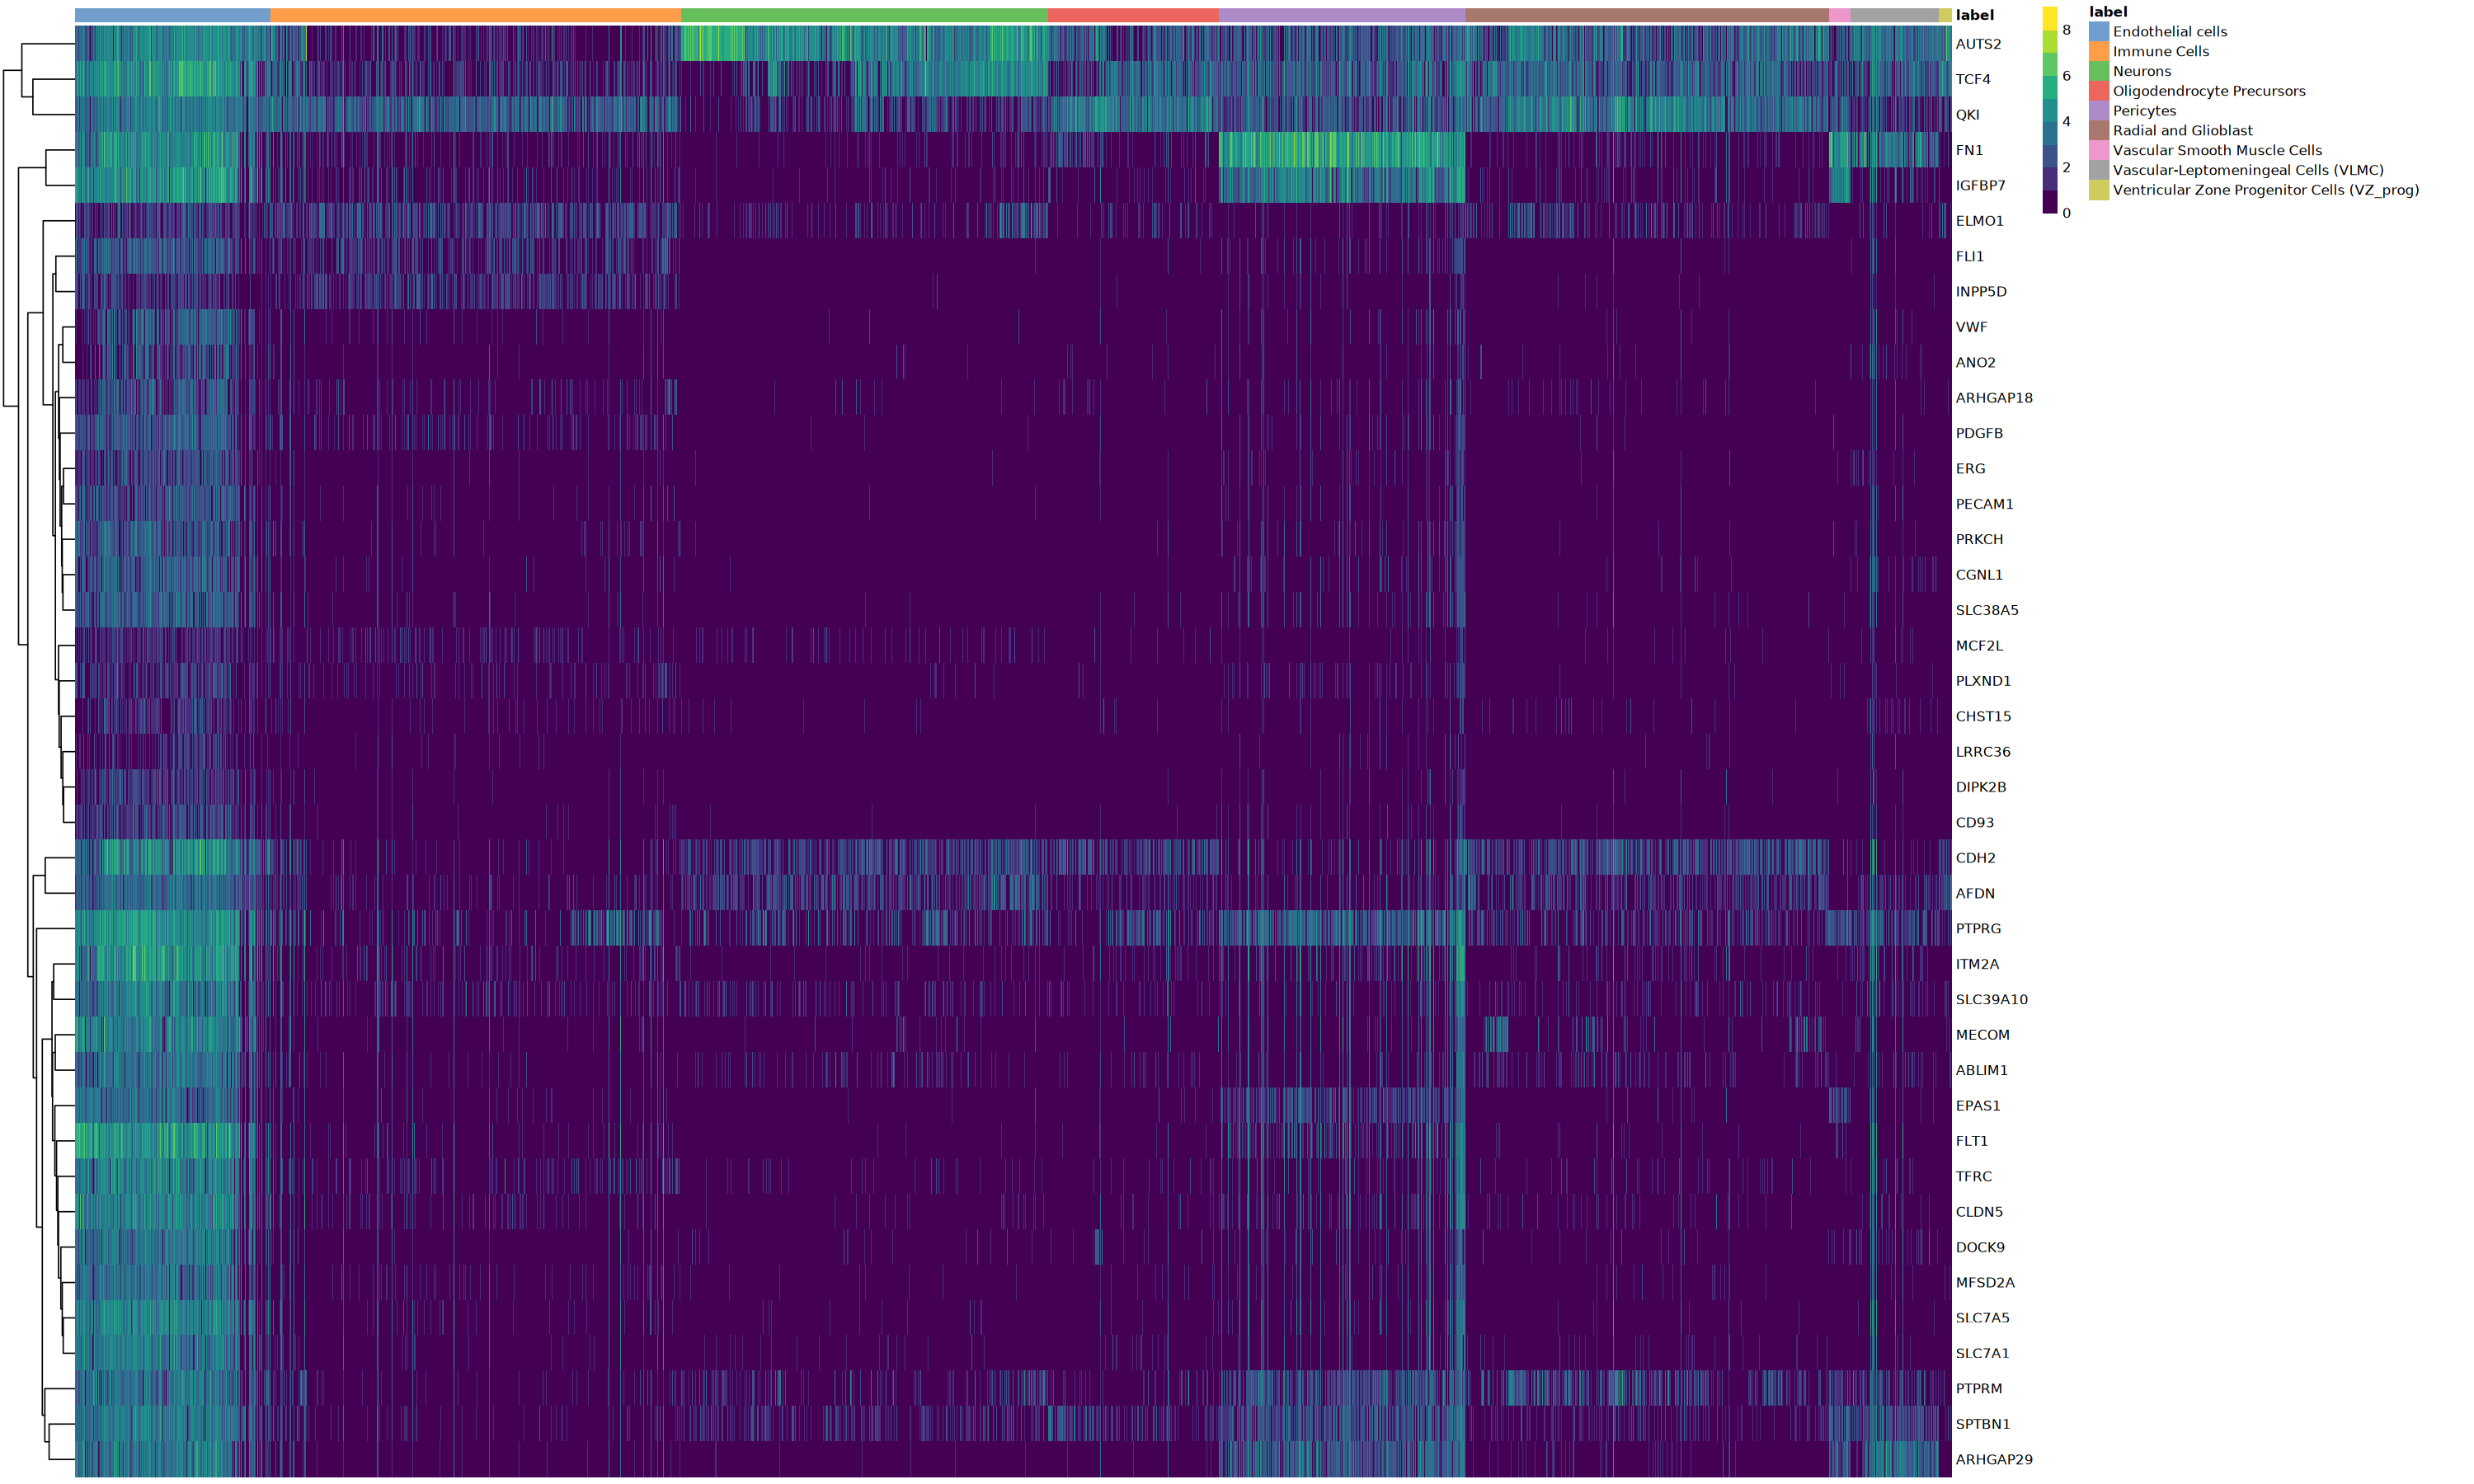

In [78]:
options(repr.plot.width = 25, repr.plot.height = 15)

plotHeatmap(sce_RNA, features=top.markers, order_columns_by="label")

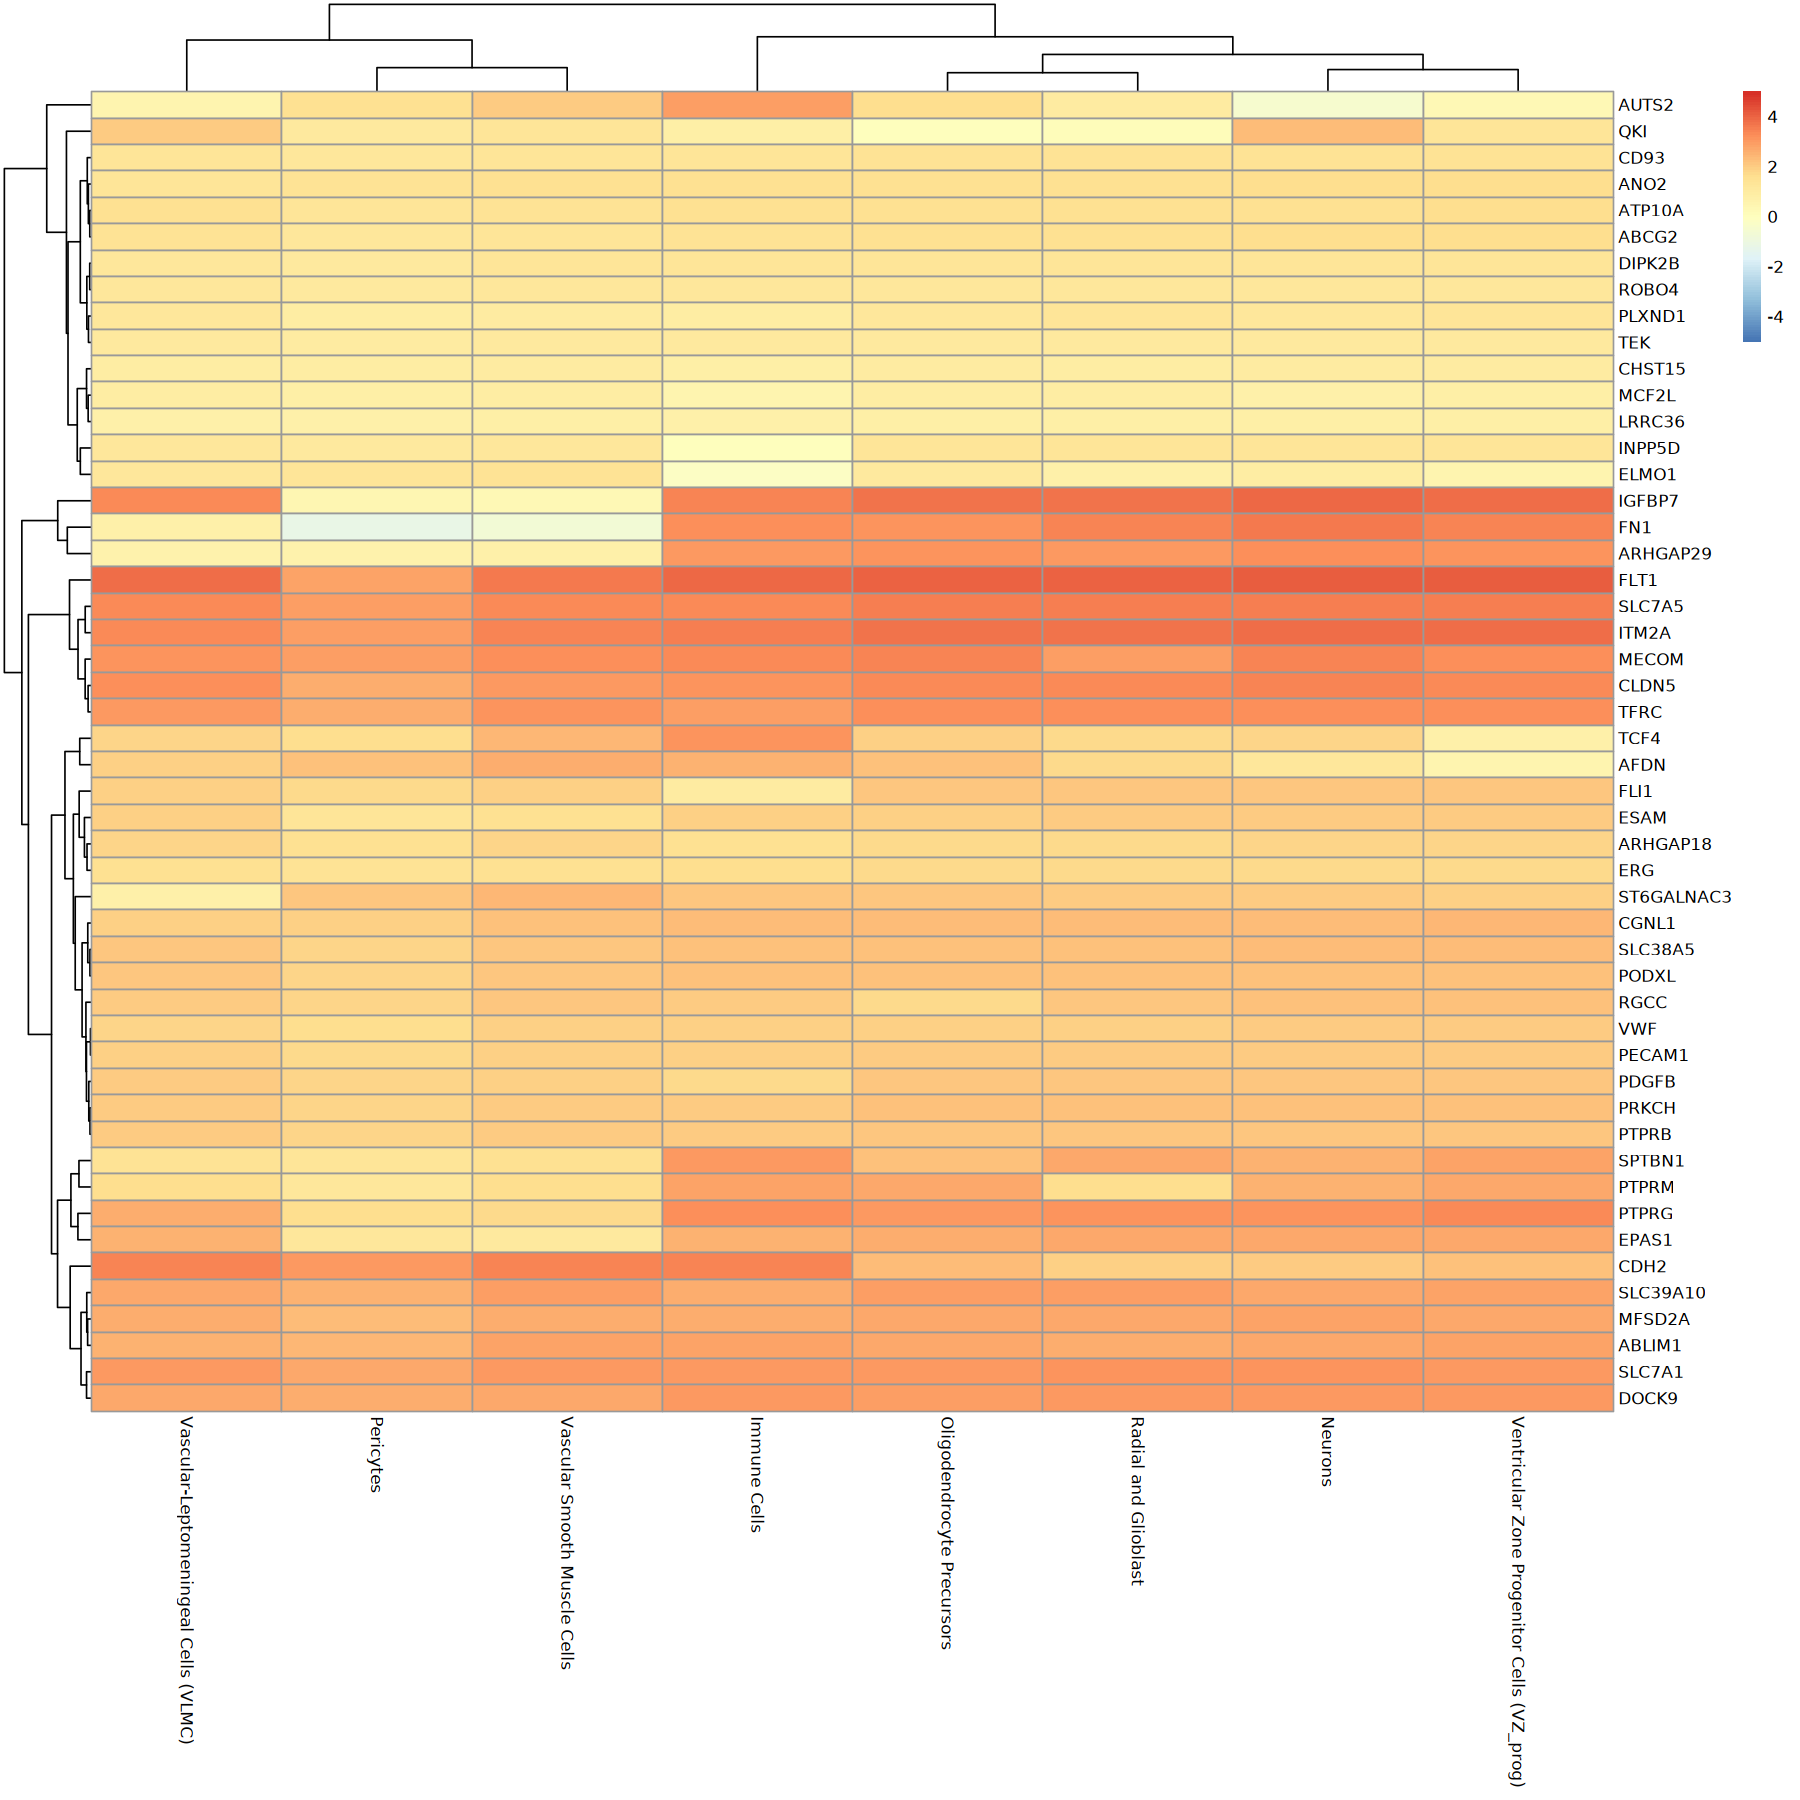

In [80]:
library(pheatmap)
logFCs <- getMarkerEffects(marker.set[1:50,])

options(repr.plot.width = 15, repr.plot.height = 15)

pheatmap(logFCs, breaks=seq(-5, 5, length.out=101))

In [81]:
# Heatmap of the log-fold changes of the top markers for endothelial cells compared to each other cell types.

In [82]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-unknown-linux-gnu
Running under: Red Hat Enterprise Linux 9.4 (Plow)

Matrix products: default
BLAS/LAPACK: /gnu/store/mj1kw87qd3m1q7r4844adkn5hifx8k6a-openblas-0.3.20/lib/libopenblasp-r0.3.20.so;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=C          LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C.UTF-8
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] pheatmap_1.0.12             BiocSingular_1.20.0        
 [3] scran_1.32.0                org.Hs.eg.db_3.19.1        
 [5] AnnotationDbi_1.66.0        scater_1.32.1              
 [7] ggplot2_3.5.1               scuttle_1.14.0             
 [9] SingleCellExperiment_1